# Exploratory Data Analysis (EDA)
## Supply Chain Disruption Risk
This section explores the structure, quality, distributions, relationships,
and potential patterns in the supply chain risk dataset.
The main objective is to understand the data before building the
machine learning model.

In [81]:
# ============================================================
# 01. IMPORTS & CONFIGURATION
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
# Visualization settings
sns.set_theme(style="whitegrid")
# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

## 2. Load the Dataset
The dataset contains observations related to supply chain conditions
and their corresponding risk levels.

In [82]:
# ============================================================
# 02. LOAD DATASET
# ============================================================
file_path = "supply_20000.csv"
df = pd.read_csv(file_path)
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

Rows    : 20,000
Columns : 13


In [83]:
# First five rows
display(df.head())

,Timestamp,Supplier_ID,Port_Congestion,geopolitical_risk,weather_severity,Supplier_Reliability,Supplier_Capacity_Utilization,Inventory_Level,Demand_Volatility,Lead_Time_Days,Shipping_Cost_Index,Risk_Level,Risk_Score
0,2025-01-01,1001,0.283,0.300,0.523,0.871,0.488,3131,0.310,7,115.494,Low,0.729
1,2025-01-02,1001,0.212,0.292,0.500,0.845,0.452,2916,0.303,10,100.505,Low,0.575
2,2025-01-03,1001,0.202,0.280,0.545,0.828,0.391,2808,0.310,9,107.522,Low,0.797
3,2025-01-04,1001,0.234,0.299,0.522,0.819,0.404,2619,0.318,10,98.861,Low,0.623
4,2025-01-05,1001,0.257,0.326,0.505,0.799,0.367,2631,0.356,12,121.167,Low,0.814


In [84]:
# Last five rows
display(df.tail())

,Timestamp,Supplier_ID,Port_Congestion,geopolitical_risk,weather_severity,Supplier_Reliability,Supplier_Capacity_Utilization,Inventory_Level,Demand_Volatility,Lead_Time_Days,Shipping_Cost_Index,Risk_Level,Risk_Score
19995,2026-01-31,1050,0.309,0.540,0.455,0.593,0.356,2327,0.453,14,121.648,Low,1.708
19996,2026-02-01,1050,0.376,0.523,0.478,0.596,0.376,2454,0.456,12,123.413,Low,2.092
19997,2026-02-02,1050,0.446,0.536,0.501,0.573,0.371,2340,0.526,14,124.432,Medium,2.794
19998,2026-02-03,1050,0.410,0.528,0.551,0.584,0.346,2613,0.523,14,121.967,Medium,2.709
19999,2026-02-04,1050,0.330,0.760,0.585,0.563,0.353,2463,0.540,14,140.375,Medium,2.759


In [85]:
# Dataset dimensions
print("Dataset Shape:", df.shape)

Dataset Shape: (20000, 13)


In [86]:
# Column names
print("Columns:")
for column in df.columns:
    print(f"- {column}")

Columns:
- Timestamp
- Supplier_ID
- Port_Congestion
- geopolitical_risk
- weather_severity
- Supplier_Reliability
- Supplier_Capacity_Utilization
- Inventory_Level
- Demand_Volatility
- Lead_Time_Days
- Shipping_Cost_Index
- Risk_Level
- Risk_Score


## 4. Dataset Structure and Data Types
We inspect the data types to identify numerical, categorical,
identifier, and time-related variables.

In [87]:
# ============================================================
# 04. DATA TYPES & STRUCTURE
# ============================================================
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Timestamp                      20000 non-null  str    
 1   Supplier_ID                    20000 non-null  int64  
 2   Port_Congestion                20000 non-null  float64
 3   geopolitical_risk              20000 non-null  float64
 4   weather_severity               20000 non-null  float64
 5   Supplier_Reliability           20000 non-null  float64
 6   Supplier_Capacity_Utilization  20000 non-null  float64
 7   Inventory_Level                20000 non-null  int64  
 8   Demand_Volatility              20000 non-null  float64
 9   Lead_Time_Days                 20000 non-null  int64  
 10  Shipping_Cost_Index            20000 non-null  float64
 11  Risk_Level                     20000 non-null  str    
 12  Risk_Score                     20000 non-null  float64
dt

In [88]:
# Separate variables by data type
numerical_columns = df.select_dtypes(
    include=np.number
).columns.tolist()
categorical_columns = df.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()
print("Numerical Columns:")
print(numerical_columns)
print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
['Supplier_ID', 'Port_Congestion', 'geopolitical_risk', 'weather_severity', 'Supplier_Reliability', 'Supplier_Capacity_Utilization', 'Inventory_Level', 'Demand_Volatility', 'Lead_Time_Days', 'Shipping_Cost_Index', 'Risk_Score']

Categorical Columns:
['Timestamp', 'Risk_Level']


C:\Users\ASUS\AppData\Local\Temp\ipykernel_12380\2861472617.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(


In [89]:
# Identify the main project variables
target_column = "Risk_Level"
identifier_column = "Supplier_ID"
time_column = "Timestamp"
print("Target:", target_column)
print("Identifier:", identifier_column)
print("Time Column:", time_column)

Target: Risk_Level
Identifier: Supplier_ID
Time Column: Timestamp


## 5. Descriptive Statistics
Descriptive statistics help us understand the center, spread, and range
of the numerical variables.

In [90]:
# ============================================================
# 05. DESCRIPTIVE STATISTICS
# ============================================================
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Supplier_ID,20000.000,1025.500,14.431,1001.000,1013.000,1025.500,1038.000,1050.000
Port_Congestion,20000.000,0.396,0.080,0.091,0.341,0.395,0.450,0.719
geopolitical_risk,20000.000,0.603,0.127,0.226,0.515,0.580,0.680,1.000
weather_severity,20000.000,0.581,0.120,0.223,0.496,0.562,0.648,1.000
Supplier_Reliability,20000.000,0.535,0.053,0.500,0.500,0.512,0.553,0.938
Supplier_Capacity_Utilization,20000.000,0.346,0.044,0.300,0.308,0.337,0.370,0.669
Inventory_Level,20000.000,2329.507,281.014,1244.000,2140.000,2329.000,2517.000,3551.000
Demand_Volatility,20000.000,0.613,0.096,0.258,0.550,0.614,0.677,0.900
Lead_Time_Days,20000.000,15.083,1.871,6.000,14.000,15.000,16.000,23.000
Shipping_Cost_Index,20000.000,131.617,11.042,87.594,124.097,131.364,139.065,178.259


In [91]:
# Descriptive statistics for categorical variables
display(
    df[categorical_columns].describe().T
)

,count,unique,top,freq
Timestamp,20000,400,2025-01-01,50
Risk_Level,20000,3,Low,8000


## 6. Duplicate Records
Duplicate observations can affect analysis and model training.
We check for exact duplicate rows before deciding whether any action is needed.

In [92]:
# ============================================================
# 06. DUPLICATE RECORDS
# ============================================================
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows: {duplicate_count:,}")

Duplicate rows: 0

In [93]:
if duplicate_count == 0:
    print(" No duplicate rows were found.")
else:
    print(" Duplicate rows were found and should be reviewed.")

 No duplicate rows were found.


In [94]:
# ============================================================
# 07. MISSING VALUES
# ============================================================
total_missing = df.isnull().sum().sum()

print(f"Total missing values: {total_missing:,}")

if total_missing == 0:
    print("No missing values were found.")
else:
    print("Missing values were found.")

Total missing values: 0
No missing values were found.


## 8. Invalid Value and Range Checks
Some variables have meaningful numerical ranges.
We check whether any observations fall outside their expected ranges.
This step identifies potentially invalid values rather than automatically
removing unusual observations.

In [95]:
# ============================================================
# 08. INVALID VALUE CHECKS
# ============================================================
range_checks = {
    "Port_Congestion": (0, 1),
    "geopolitical_risk": (0, 1),
    "weather_severity": (0, 1),
    "Supplier_Reliability": (0, 1),
    "Supplier_Capacity_Utilization": (0, 1),
    "Demand_Volatility": (0, 1),
    "Inventory_Level": (0, np.inf),
    "Lead_Time_Days": (0, np.inf),
    "Shipping_Cost_Index": (0, np.inf)
}
invalid_report = []
for column, (lower_bound, upper_bound) in range_checks.items():
    invalid_mask = (
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    )
    invalid_count = invalid_mask.sum()
    invalid_report.append({
        "Variable": column,
        "Invalid Values": invalid_count,
        "Percentage (%)": round(
            invalid_count / len(df) * 100,
            2
        )
    })
invalid_report = pd.DataFrame(invalid_report)
display(invalid_report)

,Variable,Invalid Values,Percentage (%)
0,Port_Congestion,0,0.000
1,geopolitical_risk,0,0.000
2,weather_severity,0,0.000
3,Supplier_Reliability,0,0.000
4,Supplier_Capacity_Utilization,0,0.000
5,Demand_Volatility,0,0.000
6,Inventory_Level,0,0.000
7,Lead_Time_Days,0,0.000
8,Shipping_Cost_Index,0,0.000


In [96]:
total_invalid = invalid_report["Invalid Values"].sum()
print(f"Total invalid values detected: {total_invalid:,}")
if total_invalid == 0:
    print("No values outside the expected ranges were detected.")

Total invalid values detected: 0
No values outside the expected ranges were detected.


## 9. Target Variable Analysis
The target variable is `Risk_Level`, which contains three classes:
- Low
- Medium
- High
We examine the number and percentage of observations in each class
to understand the target distribution.

In [97]:
# ============================================================
# 09. TARGET VARIABLE
# ============================================================
target_distribution = pd.DataFrame({
    "Count": df[target_column].value_counts(),
    "Percentage (%)": (
        df[target_column]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )
})
display(target_distribution)

,Count,Percentage (%)
Risk_Level,,
Low,8000,40.000
Medium,7000,35.000
High,5000,25.000


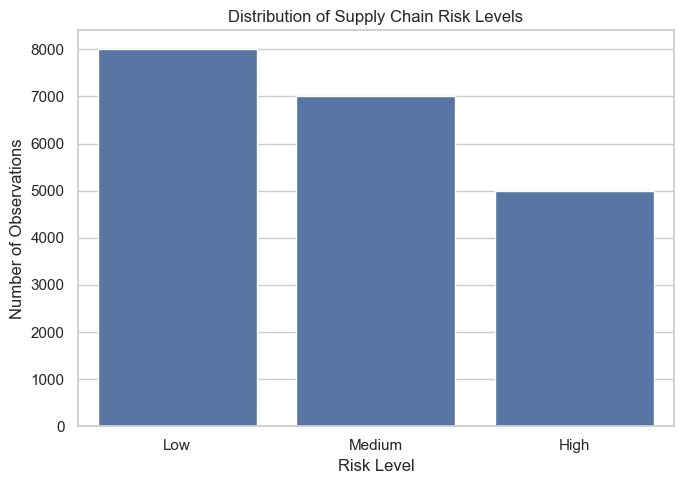

In [98]:
plt.figure(figsize=(7, 5))
sns.countplot(
    data=df,
    x=target_column,
    order=["Low", "Medium", "High"]
)
plt.title("Distribution of Supply Chain Risk Levels")
plt.xlabel("Risk Level")
plt.ylabel("Number of Observations")
plt.tight_layout()
plt.show()

### Interpretation
The target distribution is examined to determine whether the three risk
classes are reasonably represented or whether there is a substantial
class imbalance that may affect model evaluation.

## 10. Numerical Feature Distributions
Histograms are used to understand the distribution, spread, and skewness
of the numerical features.

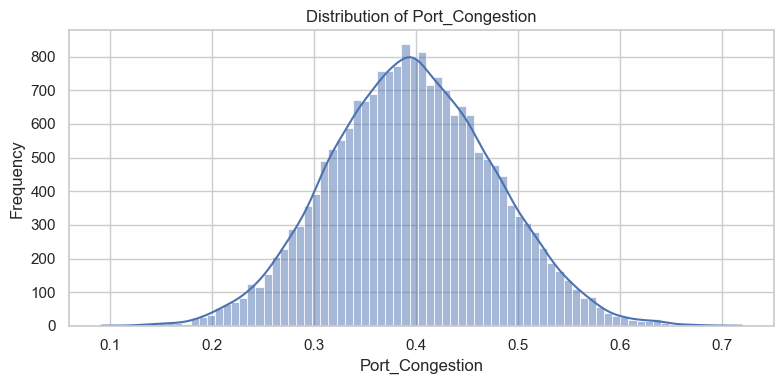

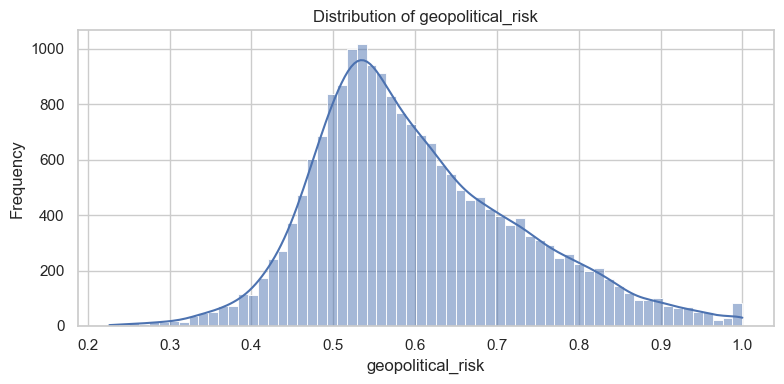

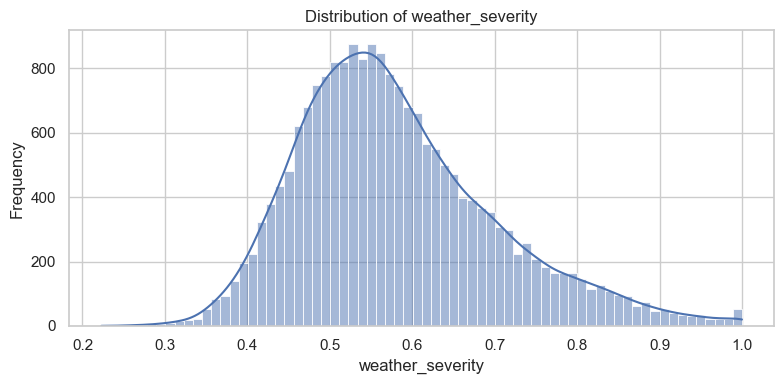

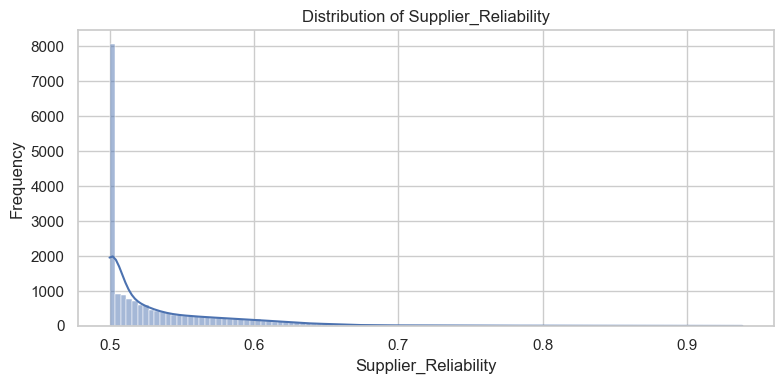

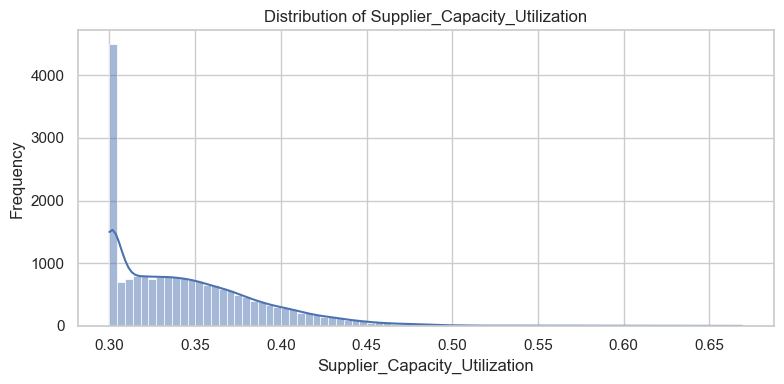

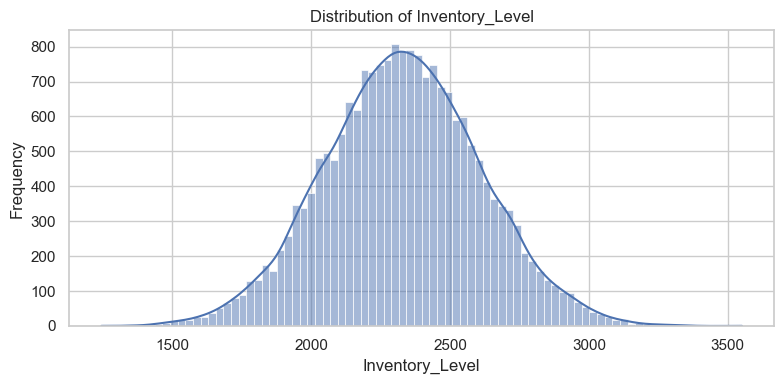

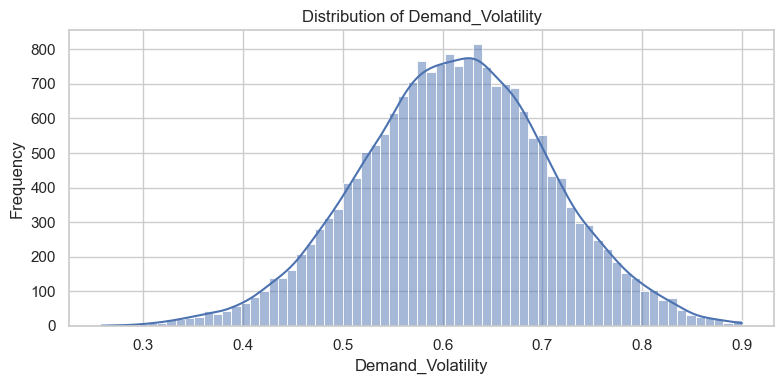

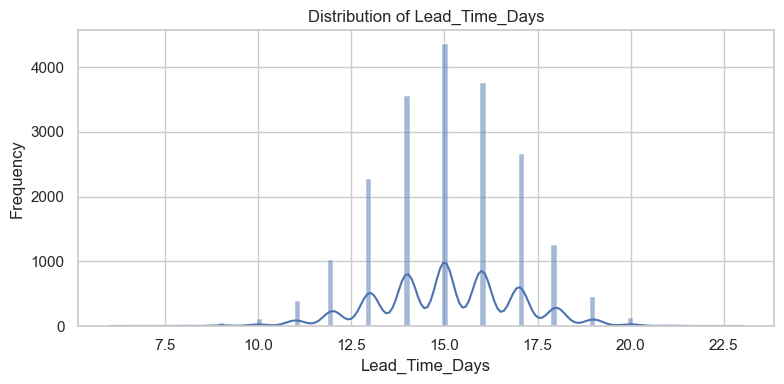

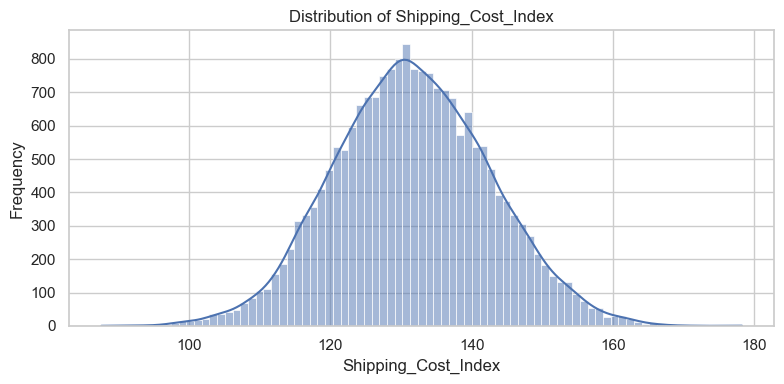

In [99]:
# ============================================================
# 10. NUMERICAL DISTRIBUTIONS
# ============================================================
feature_columns = [
    "Port_Congestion",
    "geopolitical_risk",
    "weather_severity",
    "Supplier_Reliability",
    "Supplier_Capacity_Utilization",
    "Inventory_Level",
    "Demand_Volatility",
    "Lead_Time_Days",
    "Shipping_Cost_Index"
]
for column in feature_columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(
        data=df,
        x=column,
        kde=True
    )
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

In [100]:
# Number of unique suppliers
num_suppliers = df["Supplier_ID"].nunique()

print(f"Number of unique suppliers: {num_suppliers}")

Number of unique suppliers: 50


In [101]:
suppliers = df["Supplier_ID"].unique()

print(suppliers)

[1001 1002 1003 1004 1005 1006 1007 1008 1009 1010 1011 1012 1013 1014
 1015 1016 1017 1018 1019 1020 1021 1022 1023 1024 1025 1026 1027 1028
 1029 1030 1031 1032 1033 1034 1035 1036 1037 1038 1039 1040 1041 1042
 1043 1044 1045 1046 1047 1048 1049 1050]


In [102]:
supplier_counts = df["Supplier_ID"].value_counts()

display(supplier_counts)

Supplier_ID
1001    400
1002    400
1003    400
1004    400
1005    400
1006    400
1007    400
1008    400
1009    400
1010    400
1011    400
1012    400
1013    400
1014    400
1015    400
1016    400
1017    400
1018    400
1019    400
1020    400
1021    400
1022    400
1023    400
1024    400
1025    400
1026    400
1027    400
1028    400
1029    400
1030    400
1031    400
1032    400
1033    400
1034    400
1035    400
1036    400
1037    400
1038    400
1039    400
1040    400
1041    400
1042    400
1043    400
1044    400
1045    400
1046    400
1047    400
1048    400
1049    400
1050    400
Name: count, dtype: int64

## 11. Outlier Detection Using IQR
The Interquartile Range (IQR) method is used to identify potential
extreme observations.
An IQR-based outlier is an observation below Q1 − 1.5 × IQR
or above Q3 + 1.5 × IQR.
These observations are flagged for investigation and are not
automatically considered errors.

In [103]:
# ============================================================
# 11. OUTLIER DETECTION
# ============================================================
outlier_results = []
for column in feature_columns:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_mask = (
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    )
    outlier_count = outlier_mask.sum()
    outlier_results.append({
        "Variable": column,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outliers": outlier_count,
        "Outlier Percentage (%)": (
            outlier_count / len(df) * 100
        )
    })
outlier_report = pd.DataFrame(outlier_results)
outlier_report[
    [
        "Variable",
        "Outliers",
        "Outlier Percentage (%)",
        "Lower Bound",
        "Upper Bound"
    ]
].sort_values(
    "Outlier Percentage (%)",
    ascending=False
)

,Variable,Outliers,Outlier Percentage (%),Lower Bound,Upper Bound
3,Supplier_Reliability,1072,5.360,0.421,0.632
2,weather_severity,448,2.240,0.268,0.876
1,geopolitical_risk,329,1.645,0.267,0.928
7,Lead_Time_Days,319,1.595,11.000,19.000
4,Supplier_Capacity_Utilization,298,1.490,0.215,0.463
6,Demand_Volatility,175,0.875,0.359,0.867
5,Inventory_Level,151,0.755,1574.500,3082.500
8,Shipping_Cost_Index,143,0.715,101.644,161.518
0,Port_Congestion,139,0.695,0.178,0.614


In [104]:
display(
    outlier_report.round(3)
)

,Variable,Q1,Q3,IQR,Lower Bound,Upper Bound,Outliers,Outlier Percentage (%)
0,Port_Congestion,0.341,0.450,0.109,0.178,0.614,139,0.695
1,geopolitical_risk,0.515,0.680,0.165,0.267,0.928,329,1.645
2,weather_severity,0.496,0.648,0.152,0.268,0.876,448,2.240
3,Supplier_Reliability,0.500,0.553,0.053,0.421,0.632,1072,5.360
4,Supplier_Capacity_Utilization,0.308,0.370,0.062,0.215,0.463,298,1.490
5,Inventory_Level,2140.000,2517.000,377.000,1574.500,3082.500,151,0.755
6,Demand_Volatility,0.550,0.677,0.127,0.359,0.867,175,0.875
7,Lead_Time_Days,14.000,16.000,2.000,11.000,19.000,319,1.595
8,Shipping_Cost_Index,124.097,139.065,14.969,101.644,161.518,143,0.715


## 12. visualize outlers


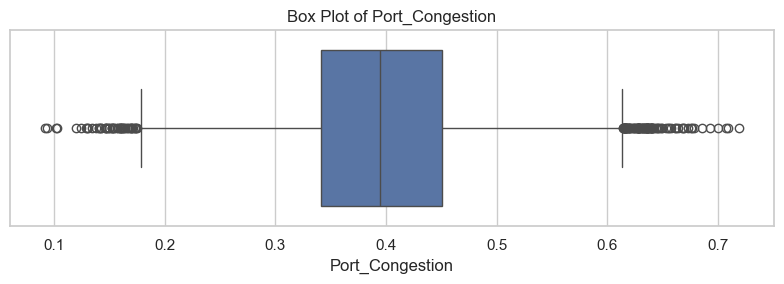

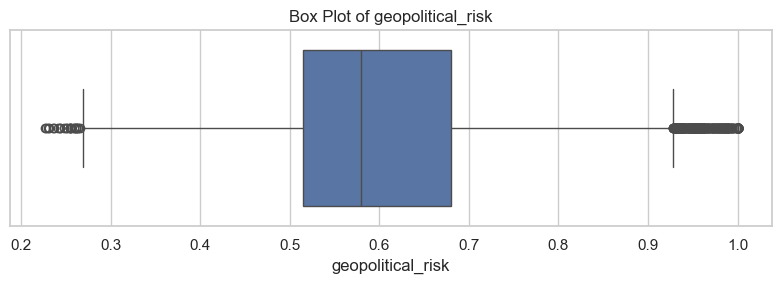

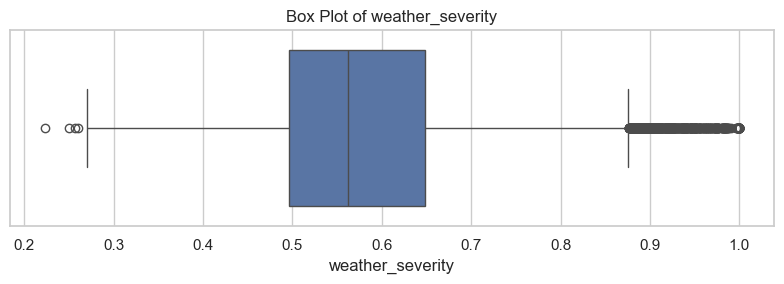

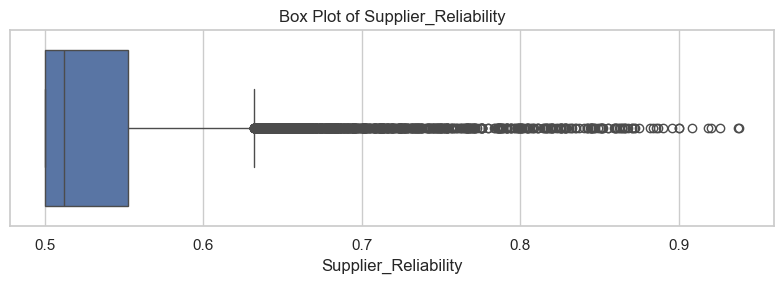

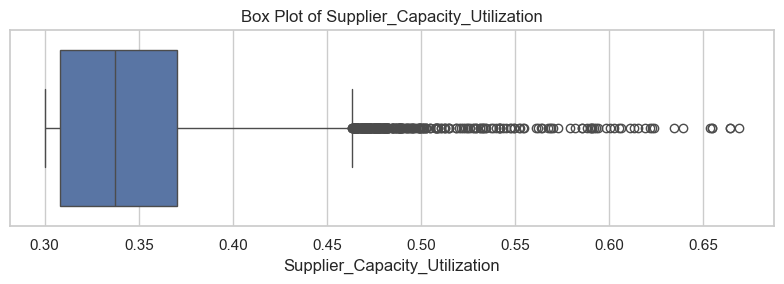

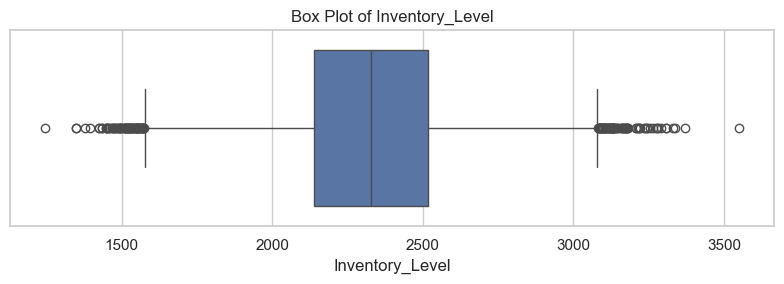

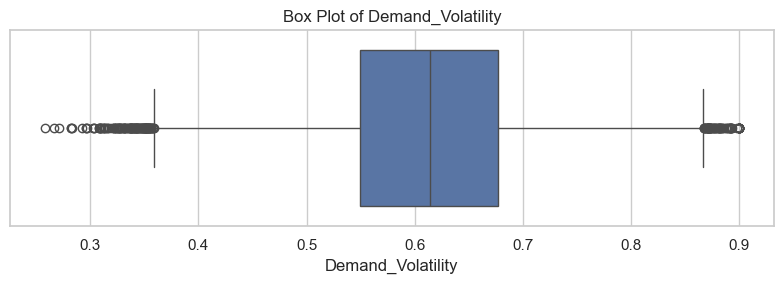

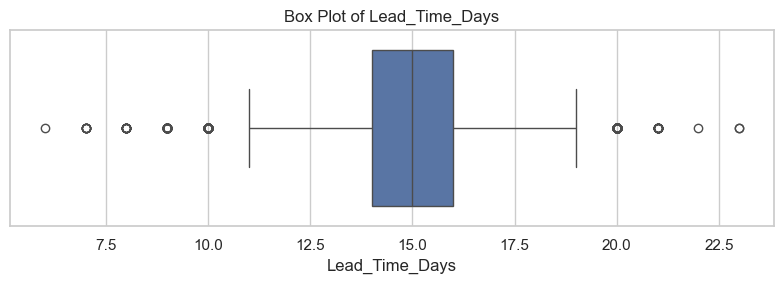

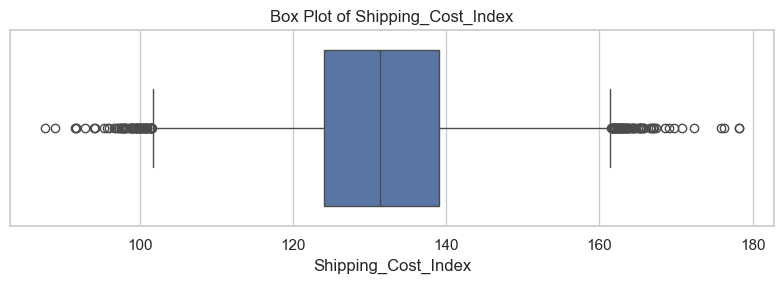

In [105]:
# ============================================================
# 12. BOXPLOTS
# ============================================================
for column in feature_columns:
    plt.figure(figsize=(8, 3))
    sns.boxplot(
        data=df,
        x=column
    )
    plt.title(f"Box Plot of {column}")
    plt.xlabel(column)
    plt.tight_layout()
    plt.show()

## 13. Feature Analysis by Risk Level
We compare the numerical features across Low, Medium, and High risk
levels to identify patterns that may help explain supply chain risk.

In [106]:
# ============================================================
# 13. GROUPED SUMMARY BY RISK LEVEL
# ============================================================
risk_summary = df.groupby(target_column)[
    feature_columns
].agg(["mean", "median", "min", "max"])
display(risk_summary.round(3).T)

Risk_Level                               High      Low   Medium
Port_Congestion               mean      0.480    0.335    0.406
                              median    0.479    0.337    0.404
                              min       0.294    0.091    0.226
                              max       0.719    0.532    0.601
geopolitical_risk             mean      0.738    0.515    0.608
                              median    0.735    0.515    0.597
                              min       0.409    0.226    0.357
                              max       1.000    0.863    0.988
weather_severity              mean      0.637    0.535    0.594
                              median    0.617    0.524    0.577
                              min       0.261    0.223    0.270
                              max       1.000    1.000    1.000
Supplier_Reliability          mean      0.510    0.563    0.522
                              median    0.500    0.543    0.508
                              min       0.500    0.500    0.500
                              max       0.642    0.938    0.691
Supplier_Capacity_Utilization mean      0.365    0.334    0.345
                              median    0.361    0.322    0.339
                              min       0.300    0.300    0.300
                              max       0.552    0.669    0.496
Inventory_Level               mean   2173.517 2457.404 2294.760
                              median 2178.000 2456.000 2297.000
                              min    1244.000 1425.000 1347.000
                              max    3217.000 3551.000 3265.000
Demand_Volatility             mean      0.641    0.586    0.624
                              median    0.639    0.588    0.625
                              min       0.353    0.258    0.315
                              max       0.900    0.888    0.900
Lead_Time_Days                mean     16.877   13.706   15.374
                              median   17.000   14.000   15.000
                              min      12.000    6.000   11.000
                              max      23.000   19.000   20.000
Shipping_Cost_Index           mean    140.574  125.257  132.487
                              median  140.672  125.404  132.416
                              min     110.087   87.594   95.296
                              max     178.259  157.594  163.317

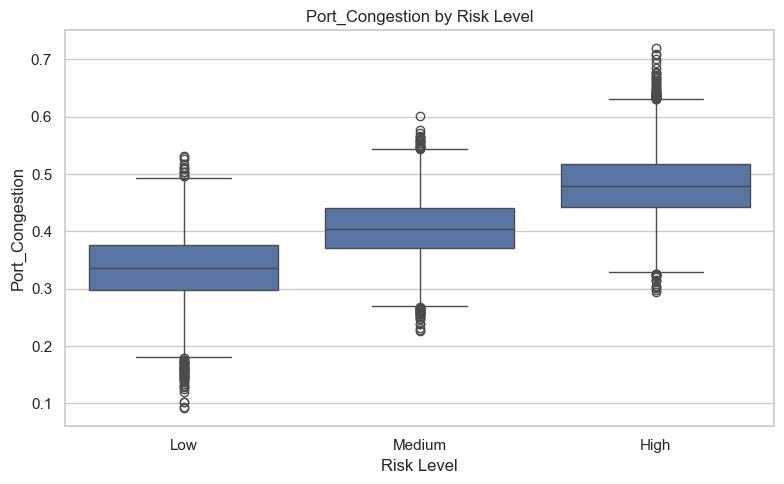

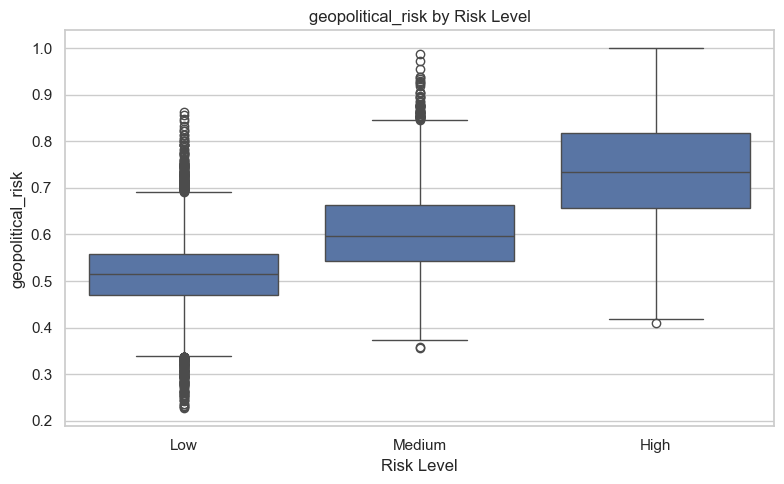

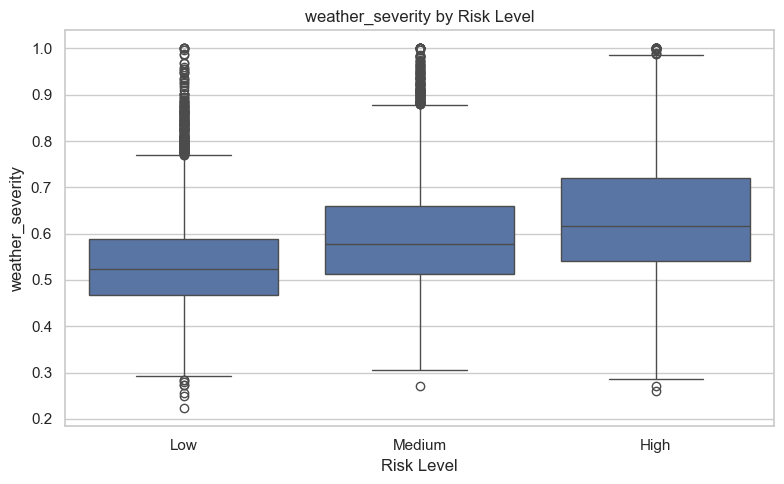

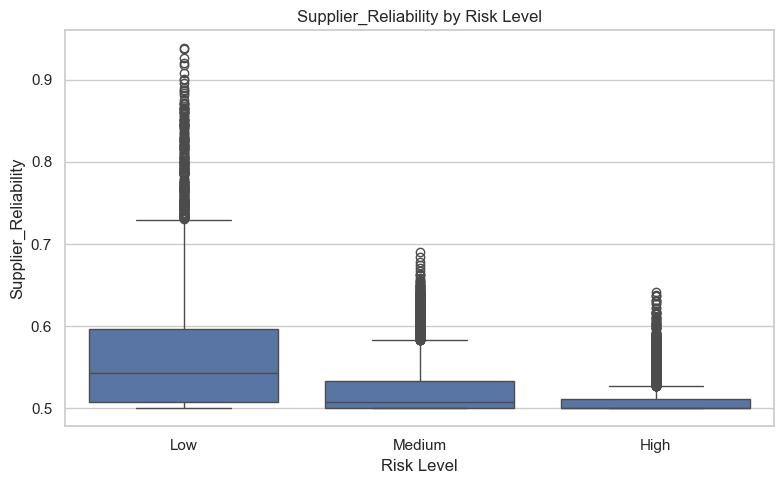

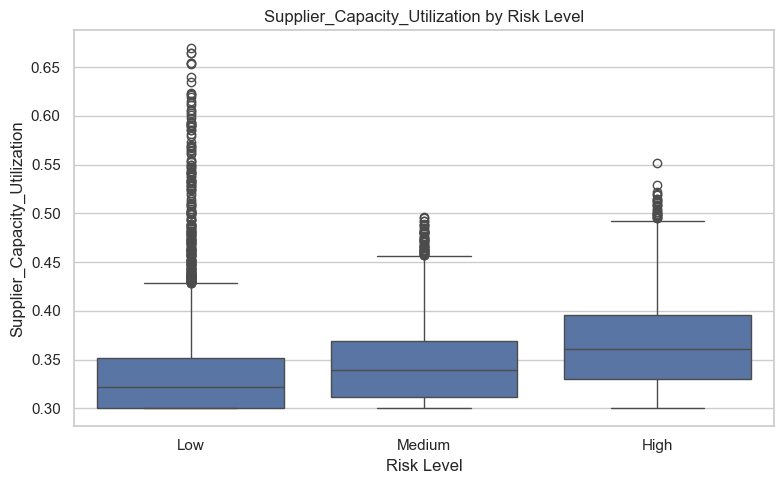

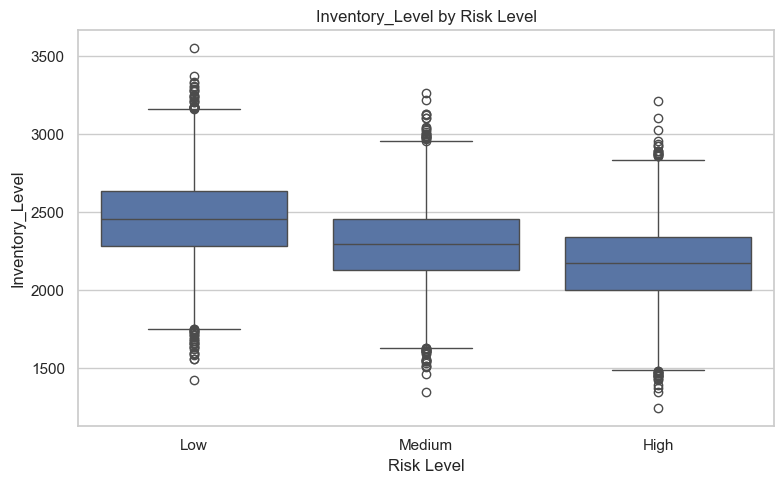

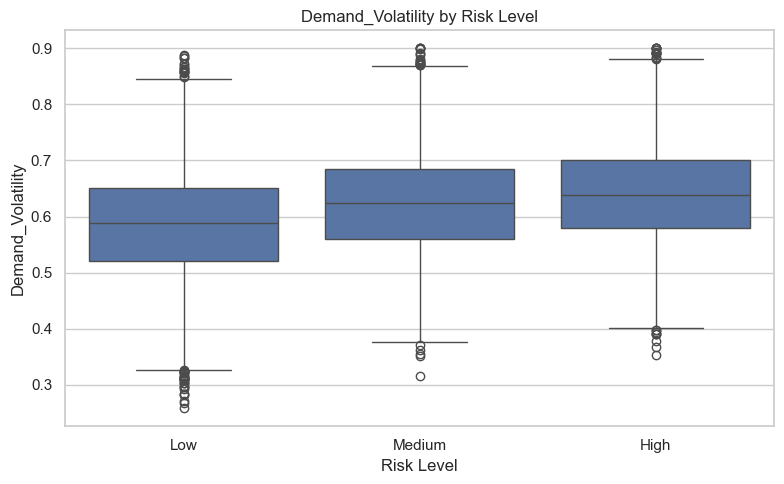

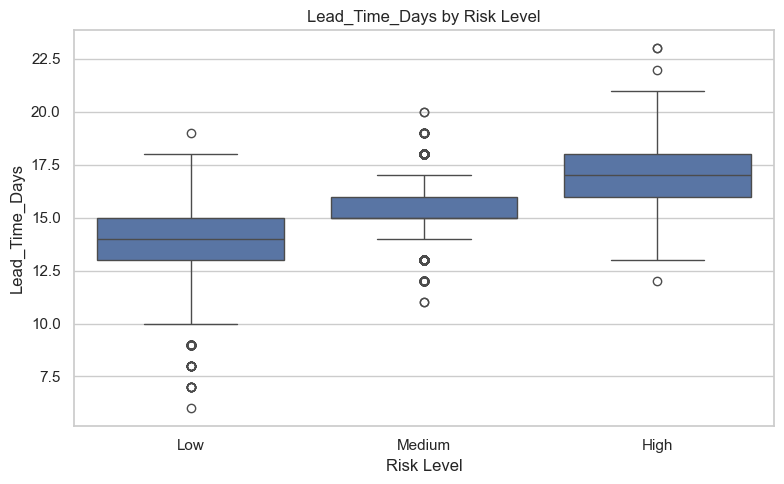

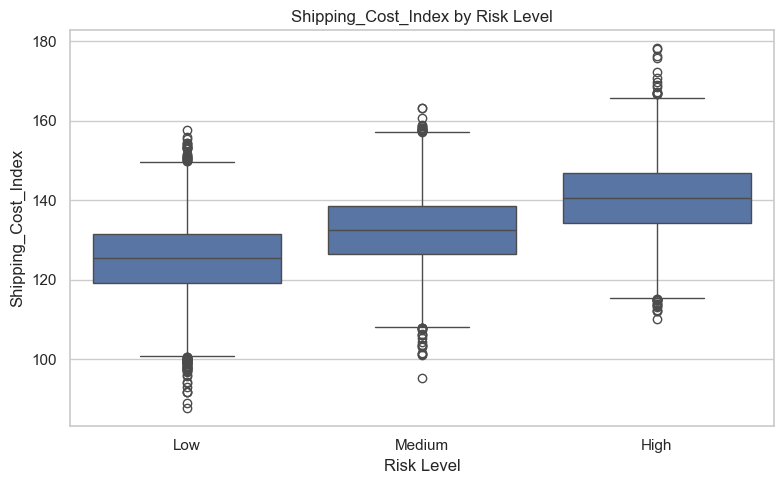

In [107]:
key_features = [
    "Port_Congestion",
    "geopolitical_risk",
    "weather_severity",
    "Supplier_Reliability",
    "Supplier_Capacity_Utilization",
    "Inventory_Level",
    "Demand_Volatility",
    "Lead_Time_Days",
    "Shipping_Cost_Index"
]

for column in key_features:

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=df,
        x=target_column,
        y=column,
        order=["Low", "Medium", "High"]
    )

    plt.title(f"{column} by Risk Level")
    plt.xlabel("Risk Level")
    plt.ylabel(column)

    plt.tight_layout()
    plt.show()

## 14. Correlation Analysis
Correlation analysis is used to examine linear relationships between
numerical features.
Correlation indicates the strength and direction of a linear relationship.
It does not establish causation.

In [108]:
# ============================================================
# 14. CORRELATION MATRIX
# ============================================================
correlation_matrix = df[feature_columns].corr()
display(
    correlation_matrix.round(3)
)

,Port_Congestion,geopolitical_risk,weather_severity,Supplier_Reliability,Supplier_Capacity_Utilization,Inventory_Level,Demand_Volatility,Lead_Time_Days,Shipping_Cost_Index
Port_Congestion,1.000,0.588,0.365,-0.350,0.299,-0.374,0.108,0.670,0.592
geopolitical_risk,0.588,1.000,0.050,-0.413,0.173,-0.305,0.128,0.616,0.590
weather_severity,0.365,0.050,1.000,-0.126,0.080,-0.121,0.033,0.200,0.148
Supplier_Reliability,-0.350,-0.413,-0.126,1.000,0.038,0.276,-0.282,-0.490,-0.328
Supplier_Capacity_Utilization,0.299,0.173,0.080,0.038,1.000,-0.086,-0.013,0.166,0.170
Inventory_Level,-0.374,-0.305,-0.121,0.276,-0.086,1.000,-0.159,-0.432,-0.289
Demand_Volatility,0.108,0.128,0.033,-0.282,-0.013,-0.159,1.000,0.143,0.099
Lead_Time_Days,0.670,0.616,0.200,-0.490,0.166,-0.432,0.143,1.000,0.604
Shipping_Cost_Index,0.592,0.590,0.148,-0.328,0.170,-0.289,0.099,0.604,1.000


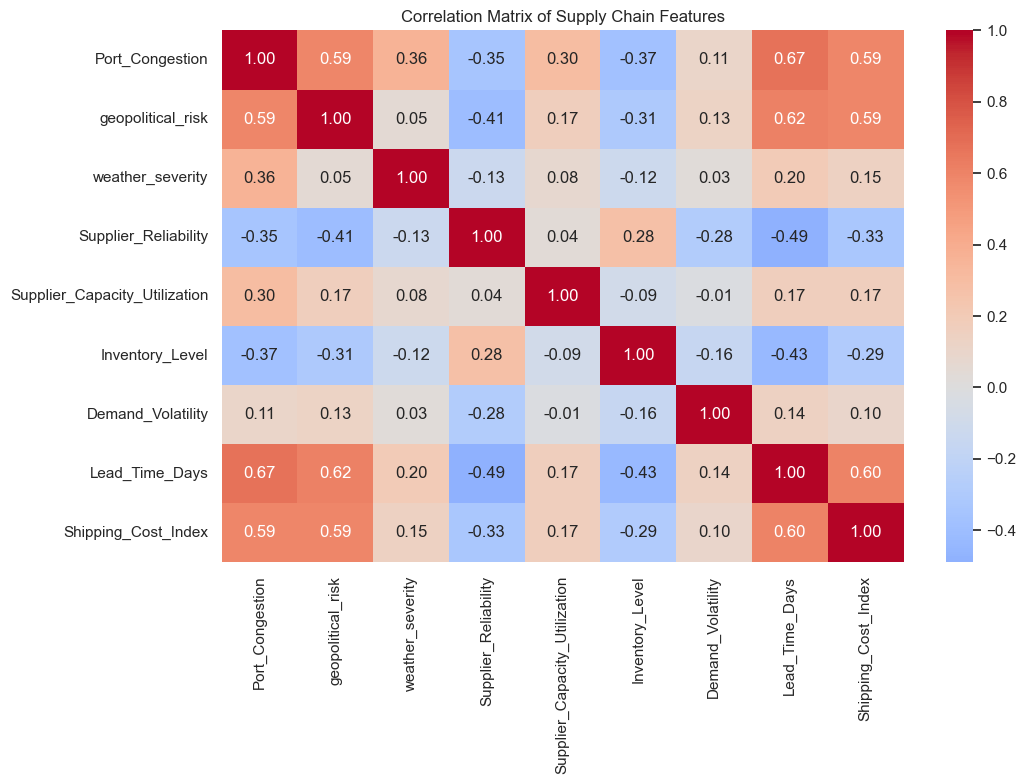

In [109]:
plt.figure(figsize=(11, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Matrix of Supply Chain Features")
plt.tight_layout()
plt.show()

In [110]:
# ============================================================
# 15. CORRELATION WITH RISK LEVEL
# ============================================================
risk_mapping = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}
df["Risk_Level_Numeric"] = (
    df[target_column].map(risk_mapping)
)
risk_correlations = (
    df[feature_columns + ["Risk_Level_Numeric"]]
    .corr()["Risk_Level_Numeric"]
    .drop("Risk_Level_Numeric")
    .sort_values()
)
display(
    risk_correlations.round(3)
)

Supplier_Reliability            -0.413
Inventory_Level                 -0.405
Demand_Volatility                0.235
Supplier_Capacity_Utilization    0.279
weather_severity                 0.339
Shipping_Cost_Index              0.547
Lead_Time_Days                   0.674
geopolitical_risk                0.687
Port_Congestion                  0.713
Name: Risk_Level_Numeric, dtype: float64

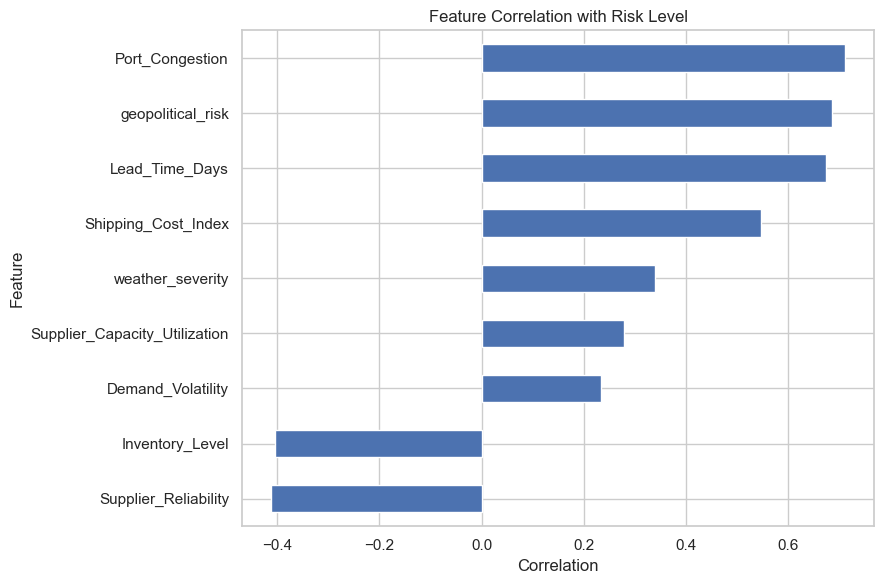

In [111]:
plt.figure(figsize=(9, 6))
risk_correlations.plot(
    kind="barh"
)
plt.title("Feature Correlation with Risk Level")
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [112]:
# ============================================================
# 16. TIME-BASED ANALYSIS
# ============================================================
df["Timestamp"] = pd.to_datetime(
    df["Timestamp"]
)
monthly_risk = (
    df.groupby(
        df["Timestamp"].dt.to_period("M")
    )[target_column]
    .value_counts()
    .unstack(fill_value=0)
)
display(monthly_risk)

Risk_Level,High,Low,Medium
Timestamp,,,
2025-01,51,1283,216
2025-02,337,634,429
2025-03,408,571,571
2025-04,433,510,557
2025-05,424,531,595
2025-06,401,545,554
2025-07,443,535,572
2025-08,462,500,588
2025-09,418,504,578


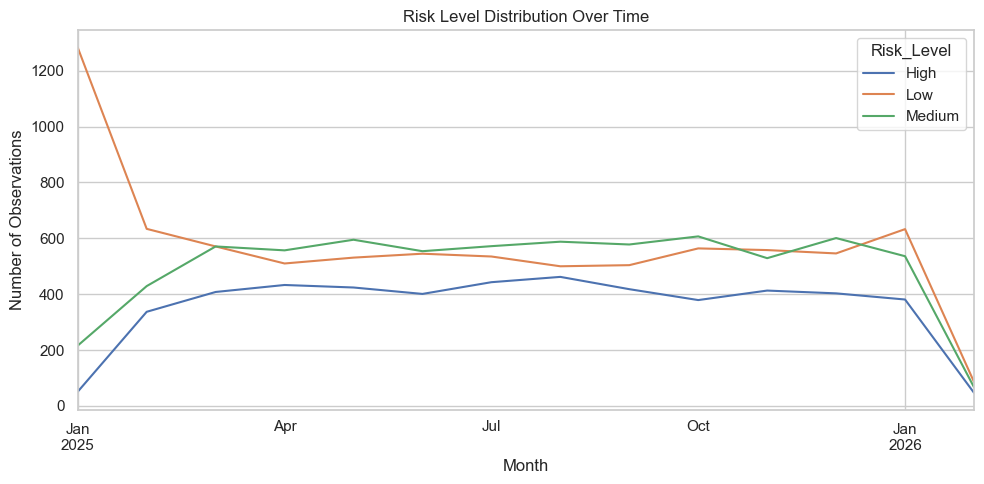

In [113]:
monthly_risk.plot(
    kind="line",
    figsize=(10, 5)
)
plt.title("Risk Level Distribution Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Observations")
plt.tight_layout()
plt.show()

# 17. Key EDA Findings
The exploratory analysis provided several important observations:
1. The dataset contains [X] observations and [X] variables.
2. No missing values were detected, so no imputation method was required.
3. [X] duplicate observations were detected.
4. No invalid values outside the expected feature ranges were detected.
5. The target variable `Risk_Level` contains three classes:
   Low, Medium, and High.
6. The analysis showed that higher values of `Port_Congestion`,
   `geopolitical_risk`, and `Lead_Time_Days` tend to be associated
   with higher risk levels in this dataset.
7. Higher `Supplier_Reliability` and `Inventory_Level` tend to be
   associated with lower risk levels.
8. Correlation analysis showed relationships among several supply-chain
   features, particularly between port congestion, lead time,
   geopolitical risk, and shipping cost.
9. IQR analysis identified potential outliers. These observations were
   reviewed rather than automatically removed because unusual values
   may represent valid supply-chain conditions.
10. Overall, the EDA suggests that supply-chain risk is influenced by
    multiple interacting factors rather than a single variable.

# 18. Final Dataset Preparation for Machine Learning
Based on the EDA findings, we prepare the variables for the machine
learning stage.
`Risk_Level` is the target variable.
`Supplier_ID` is treated as an identifier rather than a predictive
feature.
`Risk_Score` is excluded from the predictive features because it may
contain information directly related to the target and could introduce
data leakage.

In [114]:
# ============================================================
# 18. FINAL ML DATASET
# ============================================================
model_features = [
    "Port_Congestion",
    "geopolitical_risk",
    "weather_severity",
    "Supplier_Reliability",
    "Supplier_Capacity_Utilization",
    "Inventory_Level",
    "Demand_Volatility",
    "Lead_Time_Days",
    "Shipping_Cost_Index"
]
X = df[model_features].copy()
y = df[target_column].copy()
print("Features:")
print(X.columns.tolist())
print("\nTarget:")
print(y.name)
print("\nFeature Shape:", X.shape)
print("Target Shape:", y.shape)

Features:
['Port_Congestion', 'geopolitical_risk', 'weather_severity', 'Supplier_Reliability', 'Supplier_Capacity_Utilization', 'Inventory_Level', 'Demand_Volatility', 'Lead_Time_Days', 'Shipping_Cost_Index']

Target:
Risk_Level

Feature Shape: (20000, 9)
Target Shape: (20000,)


In [115]:
# ============================================================
# 19. FINAL DATA QUALITY CHECK
# ============================================================
print("Missing values in features:")
print(X.isnull().sum().sum())
print("\nMissing values in target:")
print(y.isnull().sum())
print("\nFeature data types:")
display(X.dtypes)
print("\nTarget distribution:")
display(y.value_counts())

Missing values in features:
0

Missing values in target:
0

Feature data types:


Port_Congestion                  float64
geopolitical_risk                float64
weather_severity                 float64
Supplier_Reliability             float64
Supplier_Capacity_Utilization    float64
Inventory_Level                    int64
Demand_Volatility                float64
Lead_Time_Days                     int64
Shipping_Cost_Index              float64
dtype: object


Target distribution:


Risk_Level
Low       8000
Medium    7000
High      5000
Name: count, dtype: int64

In [116]:
# ============================================================
# 20. SAVE CLEAN DATASET
# ============================================================
clean_dataset = df.copy()
clean_dataset.to_csv(
    "supply_chain_risk_clean.csv",
    index=False
)
print("✓ Clean EDA dataset saved successfully.")

✓ Clean EDA dataset saved successfully.


In [117]:
clean_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Timestamp                      20000 non-null  datetime64[us]
 1   Supplier_ID                    20000 non-null  int64         
 2   Port_Congestion                20000 non-null  float64       
 3   geopolitical_risk              20000 non-null  float64       
 4   weather_severity               20000 non-null  float64       
 5   Supplier_Reliability           20000 non-null  float64       
 6   Supplier_Capacity_Utilization  20000 non-null  float64       
 7   Inventory_Level                20000 non-null  int64         
 8   Demand_Volatility              20000 non-null  float64       
 9   Lead_Time_Days                 20000 non-null  int64         
 10  Shipping_Cost_Index            20000 non-null  float64       
 11  Risk_Level                

## 21. Feature Engineering

Time-based features are extracted from the `Timestamp` variable to capture potential temporal patterns in supply chain risk.

In [118]:
# ============================================================
# 21. FEATURE ENGINEERING
# ============================================================

# Extract month from Timestamp
df["Month"] = df["Timestamp"].dt.month

# Display the new feature
display(
    df[
        [
            "Timestamp",
            "Month"
        ]
    ].head()
)

,Timestamp,Month
0,2025-01-01,1
1,2025-01-02,1
2,2025-01-03,1
3,2025-01-04,1
4,2025-01-05,1


## 22. Train / Validation / Test Split

Since the dataset contains time-based observations, the data is split chronologically. Earlier observations are used for training, while later observations are reserved for validation and testing. This helps simulate predicting future supply-chain risk from past data.

In [ ]:
# ============================================================
# 22. TRAIN / VALIDATION / TEST SPLIT
# ============================================================

# Sort the data chronologically
df_model = df.sort_values("Timestamp").reset_index(drop=True)

# Prepare features and target
X = df_model[model_features].copy()
y = df_model[target_column].copy()

# Define split points
n = len(df_model)

train_end = int(n * 0.60)
validation_end = int(n * 0.80)

# Split chronologically
X_train = X.iloc[:train_end]
X_val = X.iloc[train_end:validation_end]
X_test = X.iloc[validation_end:]

y_train = y.iloc[:train_end]
y_val = y.iloc[train_end:validation_end]
y_test = y.iloc[validation_end:]

# Display shapes
print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)

Training set: (12000, 9) (12000,)
Validation set: (4000, 9) (4000,)
Test set: (4000, 9) (4000,)


## 23. Decision Tree



A Decision Tree classifier is used as the first baseline model for predicting the three supply-chain risk levels: Low, Medium, and High.

The model is evaluated on both the training and validation sets to assess its predictive performance and identify potential overfitting.

In [ ]:
# ============================================================
# 23. DECISION TREE
# ============================================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Create the model
dt_model = DecisionTreeClassifier(
    random_state=42
)

# Train the model
dt_model.fit(X_train, y_train)

# Predictions
y_train_pred_dt = dt_model.predict(X_train)
y_val_pred_dt = dt_model.predict(X_val)

# Calculate metrics
dt_train_accuracy = accuracy_score(y_train, y_train_pred_dt)
dt_val_accuracy = accuracy_score(y_val, y_val_pred_dt)

dt_val_precision = precision_score(
    y_val,
    y_val_pred_dt,
    average="macro"
)

dt_val_recall = recall_score(
    y_val,
    y_val_pred_dt,
    average="macro"
)

dt_val_f1 = f1_score(
    y_val,
    y_val_pred_dt,
    average="macro"
)

# Display results
print("Decision Tree Results")
print("=" * 50)

print(f"Training Accuracy : {dt_train_accuracy:.4f}")
print(f"Validation Accuracy: {dt_val_accuracy:.4f}")
print(f"Validation Precision (Macro): {dt_val_precision:.4f}")
print(f"Validation Recall (Macro):    {dt_val_recall:.4f}")
print(f"Validation F1 (Macro):        {dt_val_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        y_val_pred_dt
    )
)

Decision Tree Results
Training Accuracy : 1.0000
Validation Accuracy: 0.6965
Validation Precision (Macro): 0.7008
Validation Recall (Macro):    0.7021
Validation F1 (Macro):        0.7014

Classification Report:
              precision    recall  f1-score   support

        High       0.74      0.74      0.74      1030
         Low       0.75      0.76      0.76      1462
      Medium       0.61      0.60      0.61      1508

    accuracy                           0.70      4000
   macro avg       0.70      0.70      0.70      4000
weighted avg       0.70      0.70      0.70      4000



## 24. Random Forest

A Random Forest classifier is used as the second model for predicting the three supply-chain risk levels: Low, Medium, and High.

The model is evaluated on both the training and validation sets using Accuracy, Precision, Recall, and Macro F1-score. The training and validation performance are also compared to assess potential overfitting.

In [120]:
# ============================================================
# 24. RANDOM FOREST
# ============================================================

from sklearn.ensemble import RandomForestClassifier

# Create the model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train, y_train)

# Predictions
y_train_pred_rf = rf_model.predict(X_train)
y_val_pred_rf = rf_model.predict(X_val)

# Calculate metrics
rf_train_accuracy = accuracy_score(
    y_train,
    y_train_pred_rf
)

rf_val_accuracy = accuracy_score(
    y_val,
    y_val_pred_rf
)

rf_val_precision = precision_score(
    y_val,
    y_val_pred_rf,
    average="macro"
)

rf_val_recall = recall_score(
    y_val,
    y_val_pred_rf,
    average="macro"
)

rf_val_f1 = f1_score(
    y_val,
    y_val_pred_rf,
    average="macro"
)

# Display results
print("Random Forest Results")
print("=" * 50)

print(f"Training Accuracy : {rf_train_accuracy:.4f}")
print(f"Validation Accuracy: {rf_val_accuracy:.4f}")
print(f"Validation Precision (Macro): {rf_val_precision:.4f}")
print(f"Validation Recall (Macro):    {rf_val_recall:.4f}")
print(f"Validation F1 (Macro):        {rf_val_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        y_val_pred_rf
    )
)

Random Forest Results
Training Accuracy : 1.0000
Validation Accuracy: 0.7722
Validation Precision (Macro): 0.7844
Validation Recall (Macro):    0.7717
Validation F1 (Macro):        0.7770

Classification Report:
              precision    recall  f1-score   support

        High       0.85      0.76      0.80      1030
         Low       0.82      0.82      0.82      1462
      Medium       0.69      0.73      0.71      1508

    accuracy                           0.77      4000
   macro avg       0.78      0.77      0.78      4000
weighted avg       0.78      0.77      0.77      4000



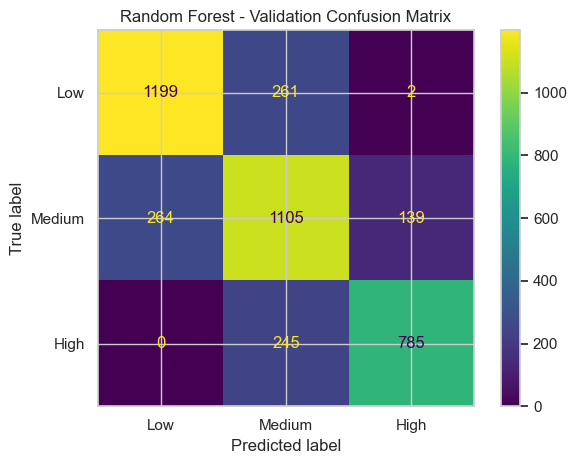

In [121]:
# ============================================================
# RANDOM FOREST - CONFUSION MATRIX
# ============================================================

cm_rf = confusion_matrix(
    y_val,
    y_val_pred_rf,
    labels=["Low", "Medium", "High"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Low", "Medium", "High"]
)

disp.plot()

plt.title("Random Forest - Validation Confusion Matrix")
plt.tight_layout()
plt.show()

## 25. XGBoost

XGBoost is used as the third classification model to predict the three supply-chain risk levels: Low, Medium, and High.

The model is evaluated using Accuracy, Macro Precision, Macro Recall, and Macro F1-score. Training and validation performance are compared to assess potential overfitting.

In [122]:
# ============================================================
# 25. XGBOOST
# ============================================================

from xgboost import XGBClassifier

# Encode target labels for XGBoost
label_mapping = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}

y_train_xgb = y_train.map(label_mapping)
y_val_xgb = y_val.map(label_mapping)

# Create the model
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="mlogloss"
)

# Train the model
xgb_model.fit(
    X_train,
    y_train_xgb
)

# Predictions
y_train_pred_xgb = xgb_model.predict(X_train)
y_val_pred_xgb = xgb_model.predict(X_val)

# Convert predictions back to original labels
reverse_mapping = {
    0: "Low",
    1: "Medium",
    2: "High"
}

y_train_pred_xgb = pd.Series(
    y_train_pred_xgb
).map(reverse_mapping)

y_val_pred_xgb = pd.Series(
    y_val_pred_xgb
).map(reverse_mapping)

# Calculate metrics
xgb_train_accuracy = accuracy_score(
    y_train,
    y_train_pred_xgb
)

xgb_val_accuracy = accuracy_score(
    y_val,
    y_val_pred_xgb
)

xgb_val_precision = precision_score(
    y_val,
    y_val_pred_xgb,
    average="macro"
)

xgb_val_recall = recall_score(
    y_val,
    y_val_pred_xgb,
    average="macro"
)

xgb_val_f1 = f1_score(
    y_val,
    y_val_pred_xgb,
    average="macro"
)

# Display results
print("XGBoost Results")
print("=" * 50)

print(f"Training Accuracy : {xgb_train_accuracy:.4f}")
print(f"Validation Accuracy: {xgb_val_accuracy:.4f}")
print(f"Validation Precision (Macro): {xgb_val_precision:.4f}")
print(f"Validation Recall (Macro):    {xgb_val_recall:.4f}")
print(f"Validation F1 (Macro):        {xgb_val_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        y_val_pred_xgb
    )
)

XGBoost Results
Training Accuracy : 0.8952
Validation Accuracy: 0.7805
Validation Precision (Macro): 0.7911
Validation Recall (Macro):    0.7801
Validation F1 (Macro):        0.7848

Classification Report:
              precision    recall  f1-score   support

        High       0.85      0.77      0.81      1030
         Low       0.83      0.83      0.83      1462
      Medium       0.70      0.74      0.72      1508

    accuracy                           0.78      4000
   macro avg       0.79      0.78      0.78      4000
weighted avg       0.78      0.78      0.78      4000



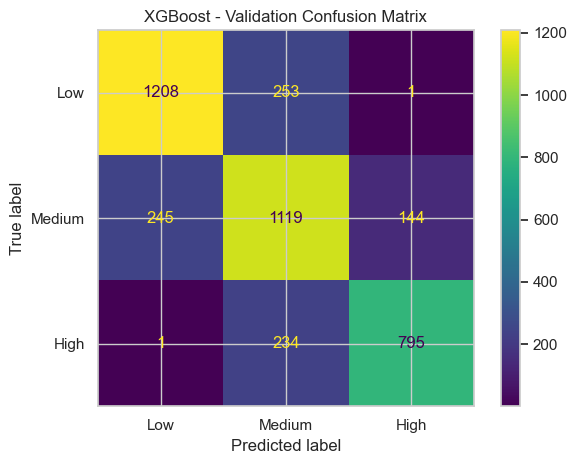

In [123]:
# ============================================================
# XGBOOST - CONFUSION MATRIX
# ============================================================

cm_xgb = confusion_matrix(
    y_val,
    y_val_pred_xgb,
    labels=["Low", "Medium", "High"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=["Low", "Medium", "High"]
)

disp.plot()

plt.title("XGBoost - Validation Confusion Matrix")
plt.tight_layout()
plt.show()

## 26. Model Comparison

The three classification models were compared using the same training and validation datasets. Accuracy, Macro Precision, Macro Recall, and Macro F1-score were used to evaluate overall performance across the three risk classes.

Macro F1-score is given particular importance because the problem involves three risk classes and provides equal importance to each class.

In [125]:
# ============================================================
# 26. MODEL COMPARISON
# ============================================================

model_comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Training Accuracy": [
        dt_train_accuracy,
        rf_train_accuracy,
        xgb_train_accuracy
    ],
    "Validation Accuracy": [
        dt_val_accuracy,
        rf_val_accuracy,
        xgb_val_accuracy
    ],
    "Validation Precision (Macro)": [
        dt_val_precision,
        rf_val_precision,
        xgb_val_precision
    ],
    "Validation Recall (Macro)": [
        dt_val_recall,
        rf_val_recall,
        xgb_val_recall
    ],
    "Validation F1 (Macro)": [
        dt_val_f1,
        rf_val_f1,
        xgb_val_f1
    ]
})

display(
    model_comparison.round(4)
)

,Model,Training Accuracy,Validation Accuracy,Validation Precision (Macro),Validation Recall (Macro),Validation F1 (Macro)
0,Decision Tree,1.000,0.697,0.701,0.702,0.701
1,Random Forest,1.000,0.772,0.784,0.772,0.777
2,XGBoost,0.895,0.780,0.791,0.780,0.785


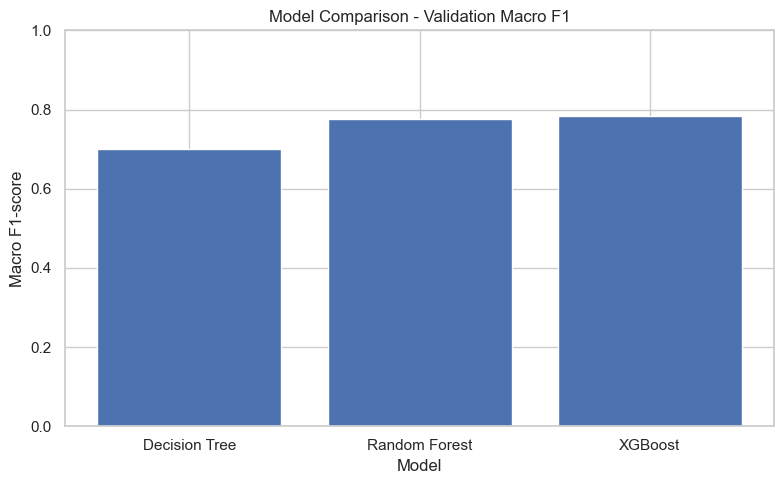

In [126]:
# ============================================================
# MODEL COMPARISON - MACRO F1
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    model_comparison["Model"],
    model_comparison["Validation F1 (Macro)"]
)

plt.title("Model Comparison - Validation Macro F1")
plt.xlabel("Model")
plt.ylabel("Macro F1-score")

plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [128]:
# ============================================================
# 27. FINAL MODEL SELECTION
# ============================================================

final_model = xgb_model

print("Final model selected: XGBoost")
print(f"Validation Accuracy: {xgb_val_accuracy:.4f}")
print(f"Validation Macro F1: {xgb_val_f1:.4f}")

Final model selected: XGBoost
Validation Accuracy: 0.7805
Validation Macro F1: 0.7848


In [129]:
# ============================================================
# 28. FINAL TEST EVALUATION
# ============================================================

# Predict on the unseen test set
y_test_xgb = y_test.map(label_mapping)

y_test_pred = final_model.predict(X_test)

# Convert predictions back to labels
y_test_pred = pd.Series(y_test_pred).map(reverse_mapping)

# Calculate test metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(
    y_test,
    y_test_pred,
    average="macro"
)
test_recall = recall_score(
    y_test,
    y_test_pred,
    average="macro"
)
test_f1 = f1_score(
    y_test,
    y_test_pred,
    average="macro"
)

print("Final Model - Test Results")
print("--------------------------")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision (Macro): {test_precision:.4f}")
print(f"Test Recall (Macro): {test_recall:.4f}")
print(f"Test F1 (Macro): {test_f1:.4f}")

Final Model - Test Results
--------------------------
Test Accuracy: 0.7833
Test Precision (Macro): 0.7900
Test Recall (Macro): 0.7861
Test F1 (Macro): 0.7879


In [130]:
# ============================================================
# 29. TEST CLASSIFICATION REPORT
# ============================================================

print("Classification Report - Test Set")
print("---------------------------------")

print(
    classification_report(
        y_test,
        y_test_pred,
        labels=["Low", "Medium", "High"]
    )
)

Classification Report - Test Set
---------------------------------
              precision    recall  f1-score   support

         Low       0.82      0.83      0.83      1489
      Medium       0.70      0.71      0.71      1460
        High       0.85      0.82      0.83      1051

    accuracy                           0.78      4000
   macro avg       0.79      0.79      0.79      4000
weighted avg       0.78      0.78      0.78      4000



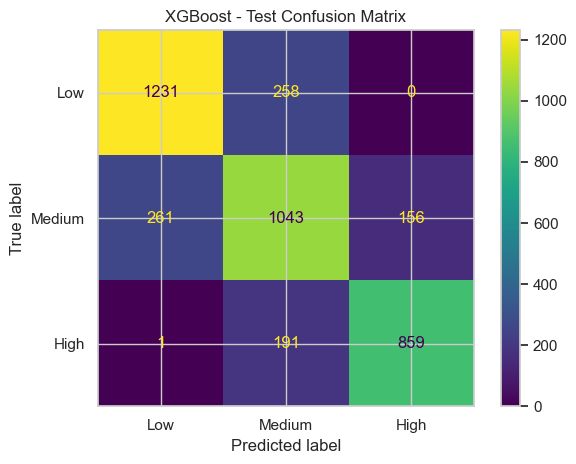

In [131]:
# ============================================================
# 30. TEST CONFUSION MATRIX
# ============================================================

cm_test = confusion_matrix(
    y_test,
    y_test_pred,
    labels=["Low", "Medium", "High"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=["Low", "Medium", "High"]
)

disp.plot()

plt.title("XGBoost - Test Confusion Matrix")
plt.tight_layout()
plt.show()

In [132]:
# ============================================================
# 31. FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": final_model.feature_importances_
})

# Sort from most important to least important
feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

display(feature_importance)

,Feature,Importance
0,Port_Congestion,0.390
7,Lead_Time_Days,0.220
1,geopolitical_risk,0.144
3,Supplier_Reliability,0.057
2,weather_severity,0.055
6,Demand_Volatility,0.054
5,Inventory_Level,0.035
4,Supplier_Capacity_Utilization,0.026
8,Shipping_Cost_Index,0.020


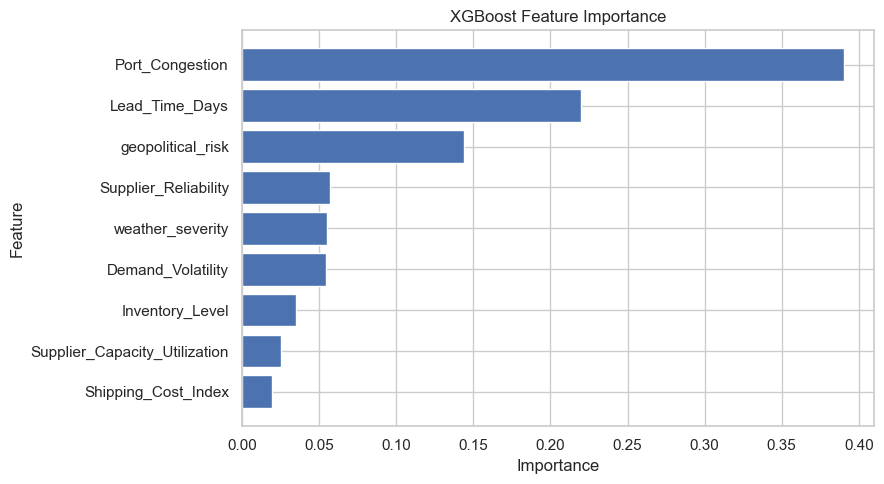

In [134]:
plt.figure(figsize=(9, 5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [136]:
# ============================================================
# 32. SAVE FINAL MODEL
# ============================================================

from pathlib import Path
import joblib

artifacts_path = Path("artifacts")
artifacts_path.mkdir(exist_ok=True)

joblib.dump(final_model, artifacts_path / "model.joblib")

print("Final model saved successfully.")

Final model saved successfully.


In [138]:
# ============================================================
# 33. SAVE MODEL INFORMATION
# ============================================================

import json

model_info = {
    "model_name": "XGBoost",
    "target": "Risk_Level",
    "features": X_train.columns.tolist(),
    "validation_accuracy": float(xgb_val_accuracy),
    "validation_macro_f1": float(xgb_val_f1),
}

with open(artifacts_path / "model_info.json", "w", encoding="utf-8") as file:
    json.dump(model_info, file, indent=4)

print("Model information saved successfully.")

Model information saved successfully.


### 32. Key Findings & Insights

* The dataset contains 20,000 observations and 13 variables, with no missing values.
* Higher Port Congestion, geopolitical risk, weather severity, demand volatility, and lead time were generally associated with higher supply chain risk.
* Higher Supplier Reliability and Inventory Level were generally associated with lower risk levels.
* Port Congestion, Lead Time, and geopolitical risk were the three most important features in the final XGBoost model, with importance values of 39.0%, 22.0%, and 14.4%, respectively.
* The Medium risk class was the most difficult class for the model to predict, with a test F1-score of 0.71.
* The final XGBoost model achieved a Test Accuracy of 78.33% and a Macro F1-score of 78.79%.
* Adding Month as a feature did not improve model performance, so the final model was kept with the original nine features.


### 33. Limitations

* The dataset is synthetic and AI-generated, so its patterns may not fully represent real-world supply chain conditions.
* The model performance may differ when applied to real operational data.
* The Medium risk class was more difficult to classify than Low and High risk.
* The current model uses the available features only and does not include external real-time information such as live weather, port status, geopolitical events, or actual supplier disruptions.
* Feature importance shows how features contributed to the model's predictions, but it does not establish causal relationships.


### 34. Conclusion

Rased was developed as an AI-powered early warning system for supply chain disruption risk. The project included data preparation, exploratory data analysis, feature engineering, model development, and evaluation.

Three classification models were evaluated: Decision Tree, Random Forest, and XGBoost. XGBoost was selected as the final model based on its validation performance. Adding Month as an additional feature did not improve the results.

The final XGBoost model achieved 78.33% test accuracy and a 78.79% Macro F1-score. The model showed its strongest performance for Low and High risk classes, while Medium risk remained more challenging to classify.

The feature importance analysis showed that Port Congestion, Lead Time, and geopolitical risk were the most important features used by the model. These insights can help identify key factors associated with higher supply chain risk and support earlier risk monitoring.

As a future improvement, Rased could be developed using real-world and real-time supply chain data to improve reliability and practical deployment.

    